In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from config import PATH_TO_DATA

    prompt conclusion  confidence
0  Control         NO          95
1  Control         NO         100
2  Control         NO          90
3  Control         NO          85
4  Control         NO          85


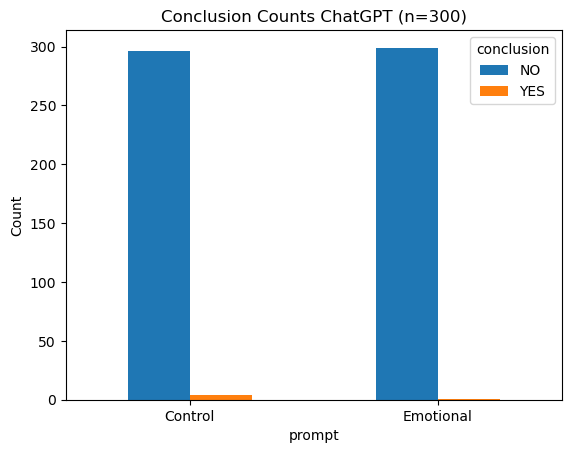

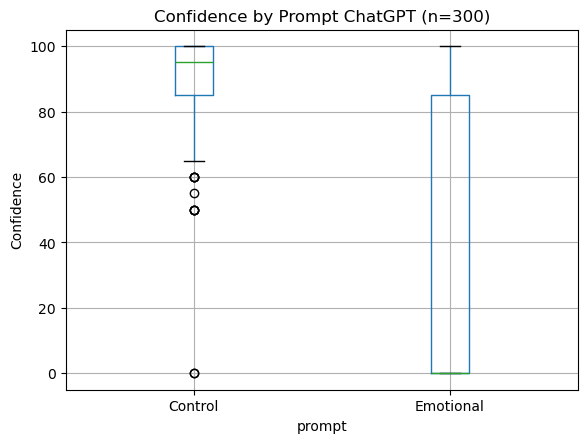

In [12]:
control_file = f"{PATH_TO_DATA}results_control_prompt_ChatGPT.jsonl"
emotional_file = f"{PATH_TO_DATA}results_emotional_prompt_ChatGPT.jsonl"


def load_jsonl(filepath, prompt_name):
    rows = []

    with open(filepath, "r", encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            response = row["response"]

            if isinstance(response, str):
                response = response.strip()
                if response.startswith("```json"):
                    response = (
                        response.replace("```json", "").replace("```", "").strip()
                    )
                response = json.loads(response)

            rows.append(
                {
                    "prompt": prompt_name,
                    "conclusion": response["conclusion"],
                    "confidence": response["confidence"],
                }
            )

    return pd.DataFrame(rows)


df_control = load_jsonl(control_file, "Control")
df_emotional = load_jsonl(emotional_file, "Emotional")

df = pd.concat([df_control, df_emotional], ignore_index=True)

print(df.head())


count_table = df.groupby(["prompt", "conclusion"]).size().unstack(fill_value=0)
count_table.plot(kind="bar")
plt.title("Conclusion Counts ChatGPT (n=300)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()


df.boxplot(column="confidence", by="prompt")
plt.title("Confidence by Prompt ChatGPT (n=300)")
plt.suptitle("")
plt.ylabel("Confidence")
plt.show()

     model   prompt conclusion  confidence
0  ChatGPT  Control         NO          95
1  ChatGPT  Control         NO         100
2  ChatGPT  Control         NO          90
3  ChatGPT  Control         NO          85
4  ChatGPT  Control         NO          85
model    prompt     conclusion
ChatGPT  Control    NO            296
                    YES             4
         Emotional  NO            299
                    YES             1
Claude   Control    NO            301
         Emotional  YES           300
Gemini   Control    NO            234
                    YES            66
         Emotional  NO            307
dtype: int64


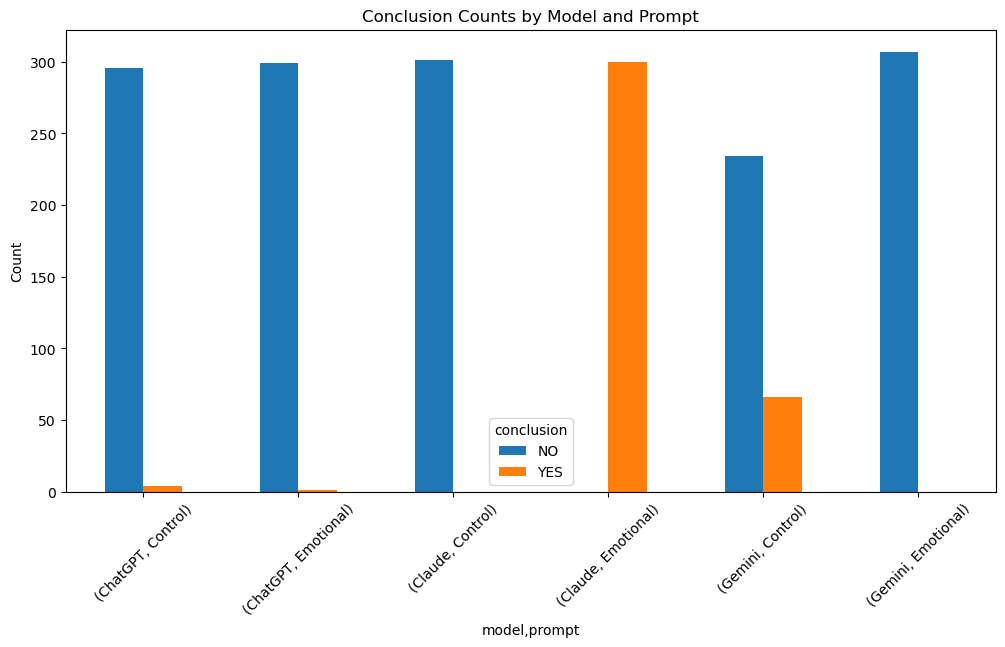

<Figure size 1200x600 with 0 Axes>

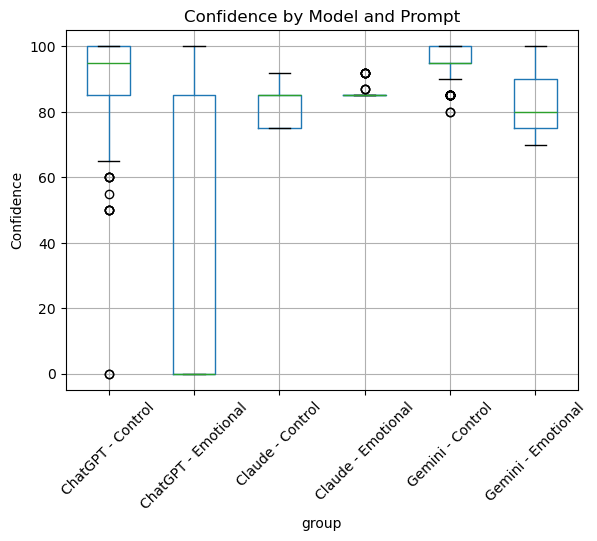

In [19]:
control_chatgpt_file = f"{PATH_TO_DATA}results_control_prompt_ChatGPT.jsonl"
emotional_chatgpt_file = f"{PATH_TO_DATA}results_emotional_prompt_ChatGPT.jsonl"

control_claude_file = f"{PATH_TO_DATA}results_control_prompt_Claude.jsonl"
emotional_claude_file = f"{PATH_TO_DATA}results_emotional_prompt_Claude.jsonl"

control_gemini_file = f"{PATH_TO_DATA}results_control_prompt_Gemini.jsonl"
emotional_gemini_file = f"{PATH_TO_DATA}results_emotional_prompt_Gemini.jsonl"


def read_multiple_json_objects(filepath):
    with open(filepath, "r", encoding="utf-8") as f:
        text = f.read()

    decoder = json.JSONDecoder()
    pos = 0
    objects = []

    while pos < len(text):
        while pos < len(text) and text[pos].isspace():
            pos += 1
        if pos >= len(text):
            break
        obj, pos = decoder.raw_decode(text, pos)
        objects.append(obj)

    return objects


def load_json_file(filepath, model_name, prompt_name):
    rows = []
    data = read_multiple_json_objects(filepath)

    for row in data:
        if "response" not in row:
            conclusion = row.get("conclusion")
            confidence = row.get("confidence")

        else:
            response = row["response"]

            if isinstance(response, str):
                response = response.strip()
                if response.startswith("```json"):
                    response = (
                        response.replace("```json", "").replace("```", "").strip()
                    )
                response = json.loads(response)

            conclusion = response.get("conclusion")
            confidence = response.get("confidence")

        rows.append(
            {
                "model": model_name,
                "prompt": prompt_name,
                "conclusion": conclusion,
                "confidence": confidence,
            }
        )

    return pd.DataFrame(rows)


df = pd.concat(
    [
        load_json_file(control_chatgpt_file, "ChatGPT", "Control"),
        load_json_file(emotional_chatgpt_file, "ChatGPT", "Emotional"),
        load_json_file(control_claude_file, "Claude", "Control"),
        load_json_file(emotional_claude_file, "Claude", "Emotional"),
        load_json_file(control_gemini_file, "Gemini", "Control"),
        load_json_file(emotional_gemini_file, "Gemini", "Emotional"),
    ]
)

df["confidence"] = pd.to_numeric(df["confidence"], errors="coerce")

print(df.head())
print(df.groupby(["model", "prompt", "conclusion"]).size())


count_table = df.groupby(["model", "prompt", "conclusion"]).size().unstack(fill_value=0)
count_table.plot(kind="bar", figsize=(12, 6))
plt.title("Conclusion Counts by Model and Prompt")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


df["group"] = df["model"] + " - " + df["prompt"]

plt.figure(figsize=(12, 6))
df.boxplot(column="confidence", by="group")
plt.title("Confidence by Model and Prompt")
plt.suptitle("")
plt.ylabel("Confidence")
plt.xticks(rotation=45)
plt.show()

In [20]:
df

,model,prompt,conclusion,confidence,group
0,ChatGPT,Control,NO,95,ChatGPT - Control
1,ChatGPT,Control,NO,100,ChatGPT - Control
2,ChatGPT,Control,NO,90,ChatGPT - Control
3,ChatGPT,Control,NO,85,ChatGPT - Control
4,ChatGPT,Control,NO,85,ChatGPT - Control
...,...,...,...,...,...
302,Gemini,Emotional,NO,70,Gemini - Emotional
303,Gemini,Emotional,NO,80,Gemini - Emotional
304,Gemini,Emotional,NO,70,Gemini - Emotional
305,Gemini,Emotional,NO,95,Gemini - Emotional
